In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded")

Libraries loaded


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix.csv to netflix (1).csv


In [ ]:
df = pd.read_csv('netflix.csv')
print(f"Shape: {df.shape}")

Shape: (8807, 12)


In [ ]:
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 3 rows:")
df.head(3)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

First 3 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


# Netflix Data Exploration and Visualization

## 1. Problem Statement

Netflix needs to make data-driven decisions about which type of shows and movies to produce and how to grow the business in different countries. This analysis explores the Netflix catalog of 8,807 titles to identify content patterns, trends, and strategic opportunities.

In [ ]:
print("BASIC METRICS")
print("=" * 50)
print(f"Total titles: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print(f"\nContent type breakdown:")
print(df['type'].value_counts())
print(f"\nRelease year range: {df['release_year'].min()} - {df['release_year'].max()}")
print(f"\nStatistical summary:")
df.describe(include='all').T

BASIC METRICS
Total titles: 8807
Total features: 12

Content type breakdown:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Release year range: 1925 - 2021

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning and Preprocessing

In [ ]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Extract year and month added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Split duration into numeric value and unit
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract('(Season|min)', expand=False)

# Convert type and rating to category
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')

print("Missing values:")
print(df.isnull().sum())
print(f"\nNew columns created: year_added, month_added, duration_num, duration_type")
print(f"\nData types after conversion:")
print(df[['date_added', 'type', 'rating', 'duration_num']].dtypes)

Missing values:
show_id             0
type                0
title               0
director         2634
cast              825
country           831
date_added         10
release_year        0
rating              4
duration            3
listed_in           0
description         0
year_added         10
month_added        10
duration_num        3
duration_type       3
dtype: int64

New columns created: year_added, month_added, duration_num, duration_type

Data types after conversion:
date_added      datetime64[ns]
type                  category
rating                category
duration_num           float64
dtype: object


## 3. Non-Graphical Analysis

In [ ]:
print("VALUE COUNTS AND UNIQUE ATTRIBUTES")
print("=" * 60)

print(f"\n--- Type ---")
print(df['type'].value_counts())

print(f"\n--- Rating (Top 10) ---")
print(df['rating'].value_counts().head(10))

print(f"\n--- Top 10 Countries ---")
# Country can have multiple values separated by comma
country_split = df['country'].dropna().str.split(',').explode().str.strip()
print(country_split.value_counts().head(10))

print(f"\n--- Top 10 Genres ---")
genre_split = df['listed_in'].str.split(',').explode().str.strip()
print(genre_split.value_counts().head(10))

print(f"\n--- Top 10 Directors ---")
director_split = df['director'].dropna().str.split(',').explode().str.strip()
print(director_split.value_counts().head(10))

print(f"\n--- Unique counts ---")
for col in ['type', 'rating', 'country', 'listed_in', 'director', 'cast']:
    if col in ['country', 'listed_in', 'director', 'cast']:
        unique = df[col].dropna().str.split(',').explode().str.strip().nunique()
    else:
        unique = df[col].nunique()
    print(f"  {col}: {unique} unique values")

VALUE COUNTS AND UNIQUE ATTRIBUTES

--- Type ---
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

--- Rating (Top 10) ---
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

--- Top 10 Countries ---
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

--- Top 10 Genres ---
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

--- Top 10

## 4. Visual Analysis

### 4.1 Univariate Analysis — Continuous Variables

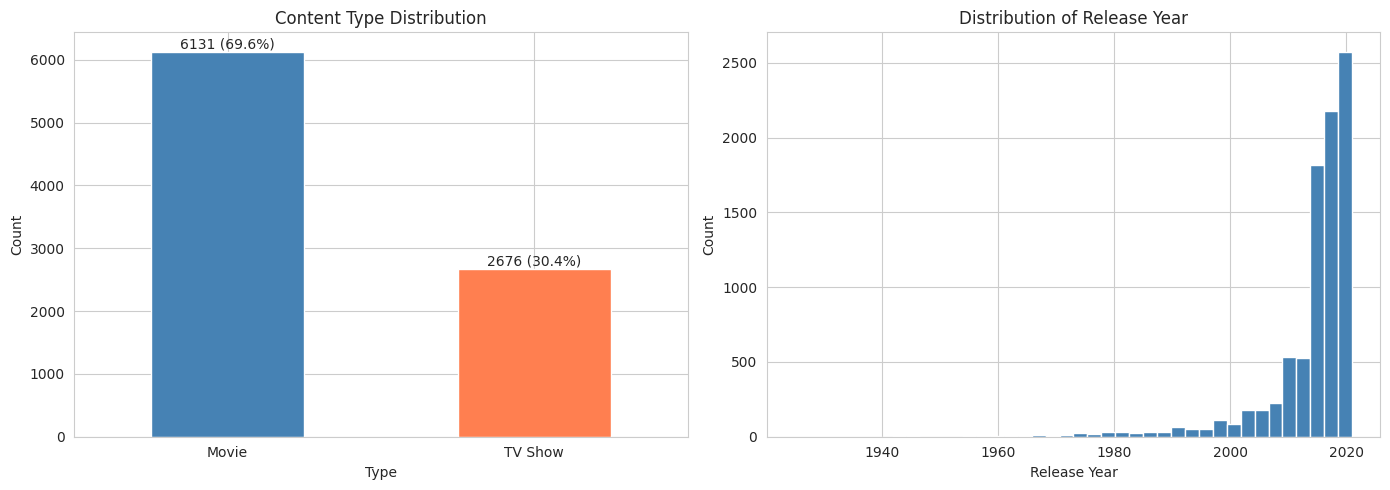

In [ ]:
# Movies vs TV Shows
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['type'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Content Type Distribution')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Add percentage labels
total = len(df)
for i, v in enumerate(df['type'].value_counts()):
    axes[0].text(i, v + 50, f'{v} ({v/total*100:.1f}%)', ha='center')

# Release year distribution
df['release_year'].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Release Year')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

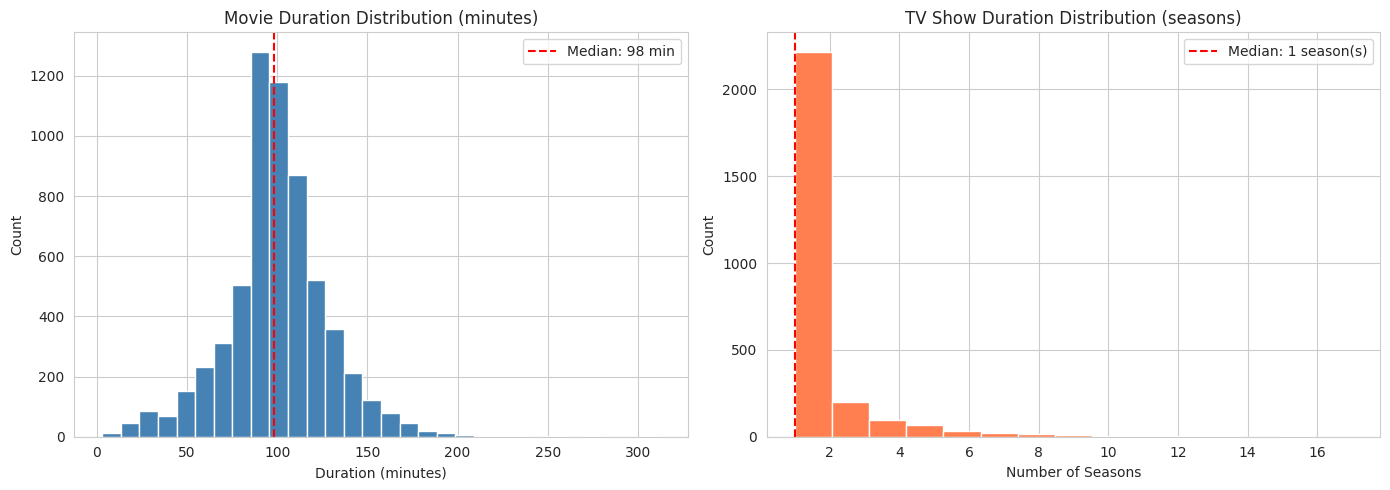

In [ ]:
# Duration distribution for movies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

movies['duration_num'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Movie Duration Distribution (minutes)')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].axvline(movies['duration_num'].median(), color='red', linestyle='--', label=f"Median: {movies['duration_num'].median():.0f} min")
axes[0].legend()

tv_shows['duration_num'].hist(bins=15, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('TV Show Duration Distribution (seasons)')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('Count')
axes[1].axvline(tv_shows['duration_num'].median(), color='red', linestyle='--', label=f"Median: {tv_shows['duration_num'].median():.0f} season(s)")
axes[1].legend()

plt.tight_layout()
plt.show()

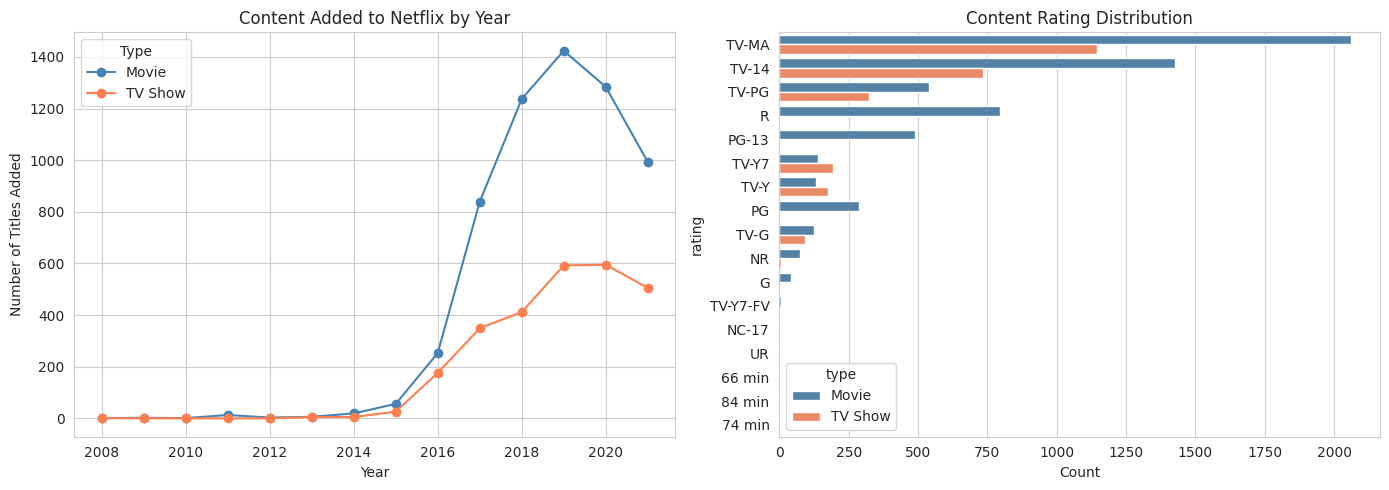

In [ ]:
# Content added over the years
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly.plot(ax=axes[0], marker='o', color=['steelblue', 'coral'])
axes[0].set_title('Content Added to Netflix by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Titles Added')
axes[0].legend(title='Type')

# Rating distribution
rating_order = df['rating'].value_counts().index
sns.countplot(data=df, y='rating', order=rating_order, hue='type', palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Content Rating Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

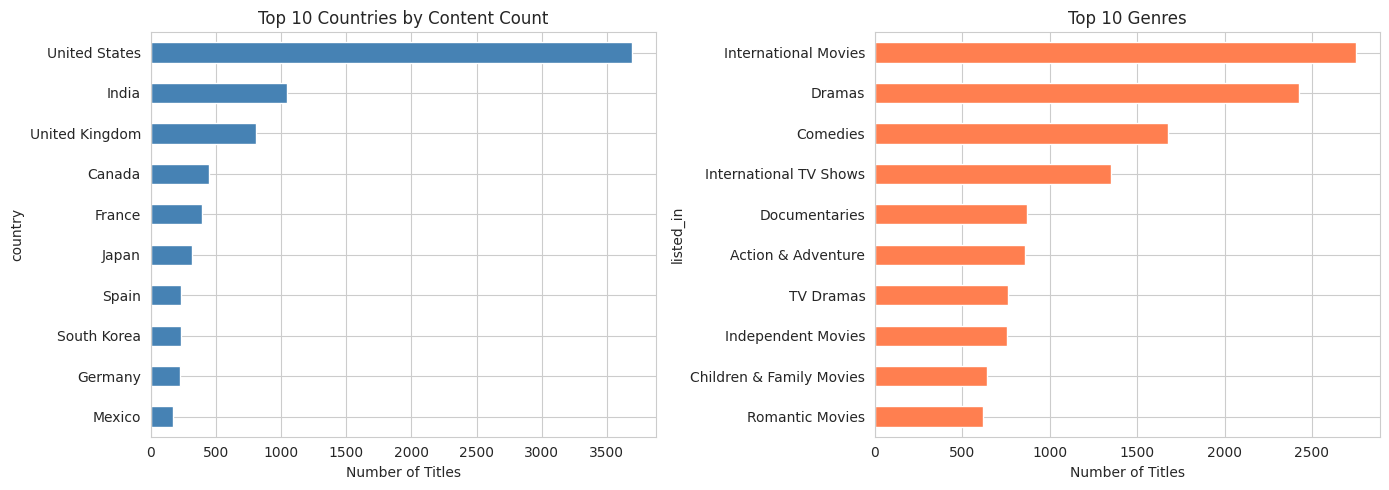

In [ ]:
# Top 10 countries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_split = df['country'].dropna().str.split(',').explode().str.strip()
top_countries = country_split.value_counts().head(10)
top_countries.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Countries by Content Count')
axes[0].set_xlabel('Number of Titles')
axes[0].invert_yaxis()

# Top 10 genres
genre_split = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genre_split.value_counts().head(10)
top_genres.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Genres')
axes[1].set_xlabel('Number of Titles')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.2 Bivariate Analysis — Categorical Variables

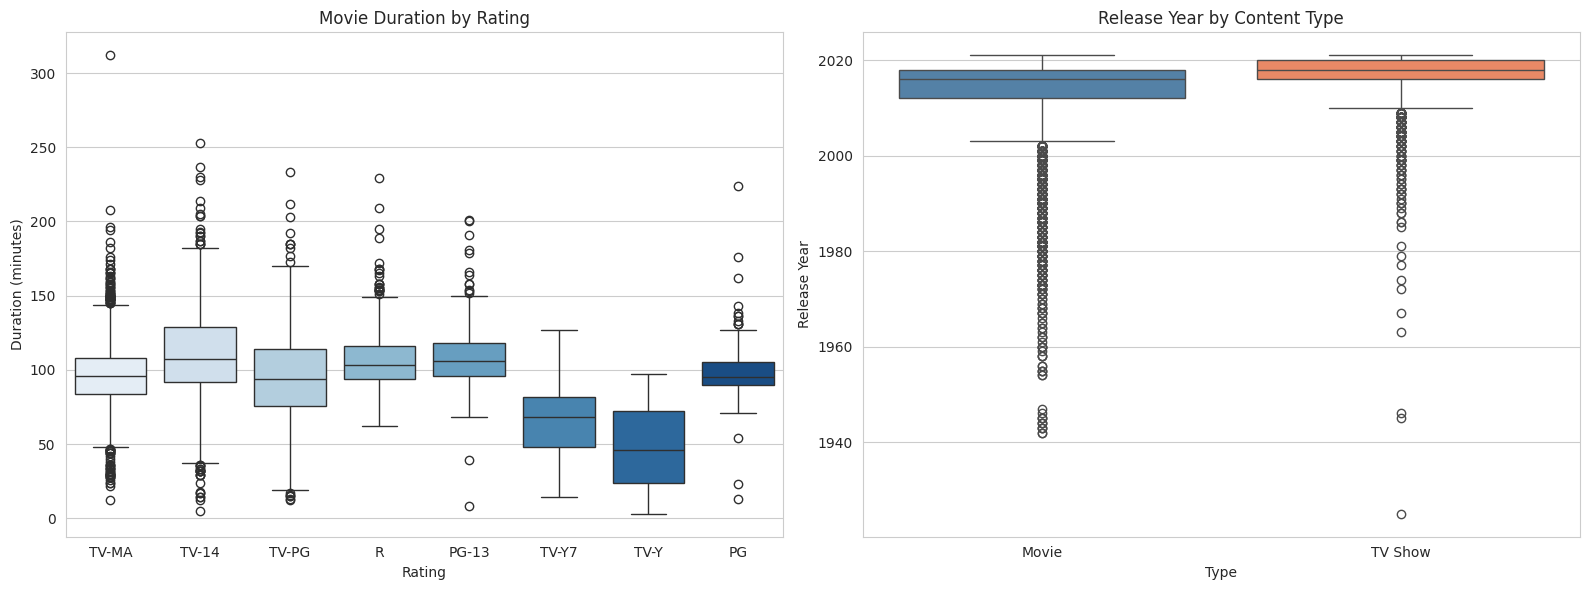

In [ ]:
# Boxplot: Movie duration by rating
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_ratings = df['rating'].value_counts().head(8).index
movies_rated = movies[movies['rating'].isin(top_ratings)]

sns.boxplot(data=movies_rated, x='rating', y='duration_num', order=top_ratings, ax=axes[0], palette='Blues')
axes[0].set_title('Movie Duration by Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Duration (minutes)')

# Boxplot: Release year by type
sns.boxplot(data=df, x='type', y='release_year', palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Release Year by Content Type')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Release Year')

plt.tight_layout()
plt.show()

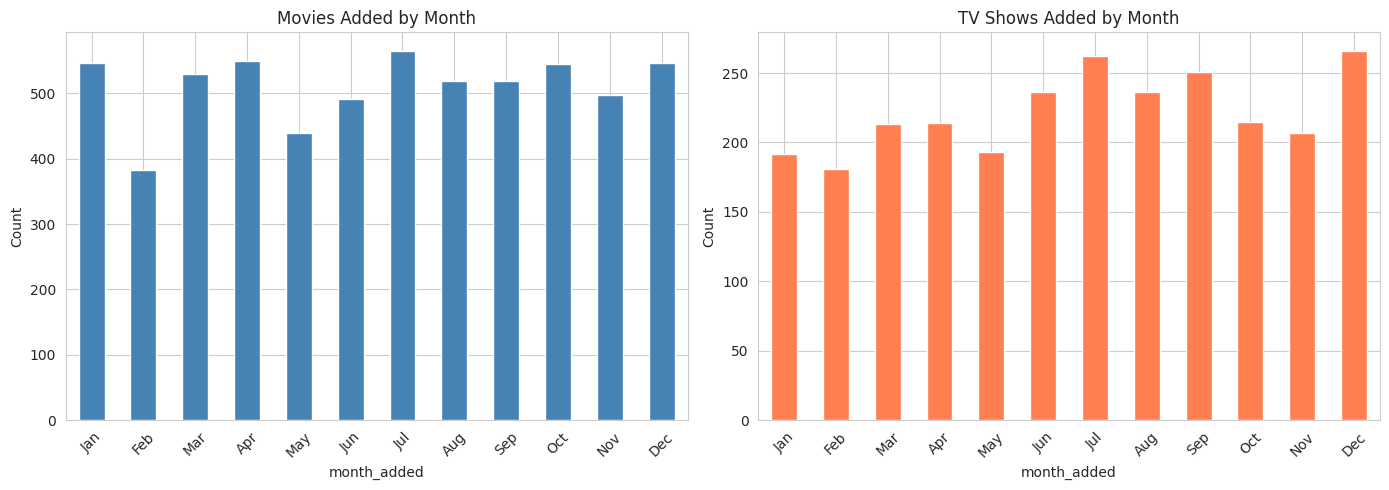

In [ ]:
# Best month to release content
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

# Movies by month
movie_months = df[df['type']=='Movie']['month_added'].dropna().value_counts().sort_index()
movie_months.index = movie_months.index.map(month_names)
movie_months.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Movies Added by Month')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# TV Shows by month
tv_months = df[df['type']=='TV Show']['month_added'].dropna().value_counts().sort_index()
tv_months.index = tv_months.index.map(month_names)
tv_months.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('TV Shows Added by Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

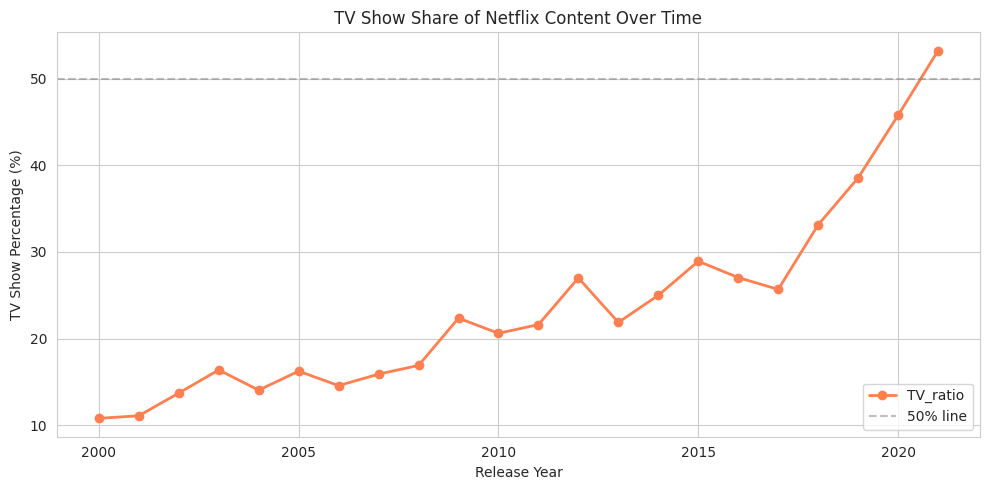

TV Show share in 2020: 45.8%
TV Show share in 2021: 53.2%


In [ ]:
# TV Shows vs Movies trend over recent years
fig, ax = plt.subplots(figsize=(10, 5))

recent = df[df['release_year'] >= 2000]
type_year = recent.groupby(['release_year', 'type']).size().unstack(fill_value=0)

# Calculate ratio
type_year['TV_ratio'] = type_year['TV Show'] / (type_year['Movie'] + type_year['TV Show']) * 100
type_year['TV_ratio'].plot(ax=ax, marker='o', color='coral', linewidth=2)
ax.set_title('TV Show Share of Netflix Content Over Time')
ax.set_xlabel('Release Year')
ax.set_ylabel('TV Show Percentage (%)')
ax.axhline(y=50, color='grey', linestyle='--', alpha=0.5, label='50% line')
ax.legend()
plt.tight_layout()
plt.show()

print(f"TV Show share in 2020: {type_year.loc[2020, 'TV_ratio']:.1f}%")
print(f"TV Show share in 2021: {type_year.loc[2021, 'TV_ratio']:.1f}%")

## 5. Missing Values and Outlier Analysis

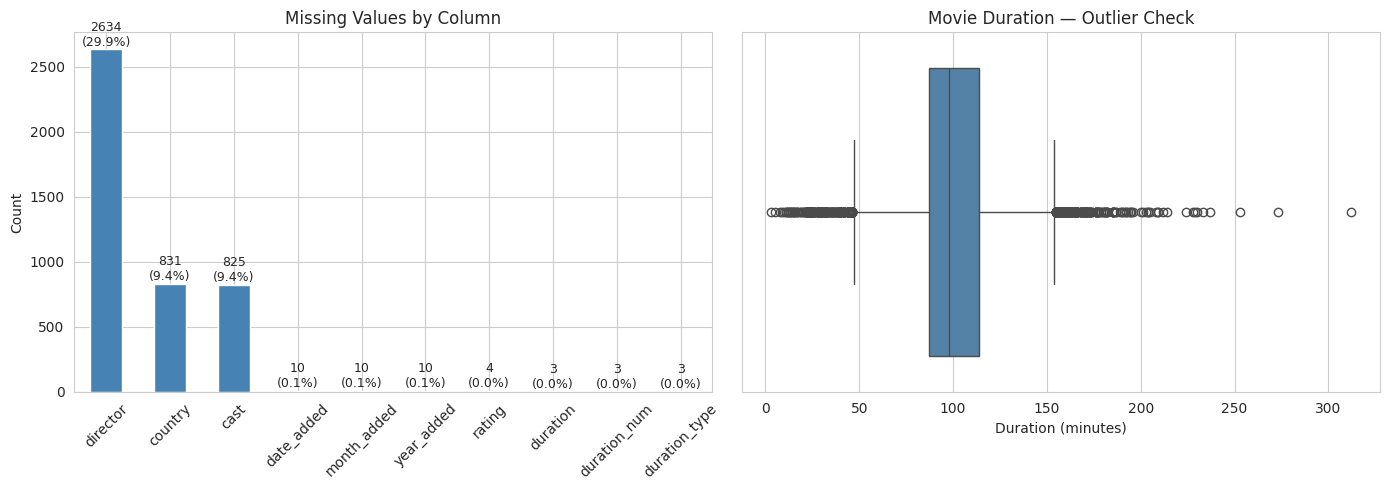

MISSING VALUE SUMMARY
Director:   2,634 missing (29.9%) — many Netflix originals have no listed director
Cast:         825 missing (9.4%) — some documentaries/specials have no cast
Country:      831 missing (9.4%) — co-productions or missing metadata
Date_added:    10 missing (0.1%) — negligible
Rating:         4 missing (0.0%) — negligible
Duration:       3 missing (0.0%) — negligible

Decision: Director, Cast, and Country are left as-is (not imputed)
since missing data is informative — it reflects actual gaps in Netflix metadata.

OUTLIER CHECK:
Movie duration median: 98 min
Movie duration range: 3 - 312 min
Movies over 180 min: 47
These long-duration titles are legitimate (extended films, concert specials) — retained.


In [ ]:
# Missing values visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values bar chart
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing Values by Column')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(missing):
    pct = v / len(df) * 100
    axes[0].text(i, v + 30, f'{v}\n({pct:.1f}%)', ha='center', fontsize=9)

# Outlier check — movie duration
sns.boxplot(x=movies['duration_num'], ax=axes[1], color='steelblue')
axes[1].set_title('Movie Duration — Outlier Check')
axes[1].set_xlabel('Duration (minutes)')

plt.tight_layout()
plt.show()

print("MISSING VALUE SUMMARY")
print("=" * 50)
print(f"Director:   2,634 missing (29.9%) — many Netflix originals have no listed director")
print(f"Cast:         825 missing (9.4%) — some documentaries/specials have no cast")
print(f"Country:      831 missing (9.4%) — co-productions or missing metadata")
print(f"Date_added:    10 missing (0.1%) — negligible")
print(f"Rating:         4 missing (0.0%) — negligible")
print(f"Duration:       3 missing (0.0%) — negligible")
print(f"\nDecision: Director, Cast, and Country are left as-is (not imputed)")
print(f"since missing data is informative — it reflects actual gaps in Netflix metadata.")
print(f"\nOUTLIER CHECK:")
print(f"Movie duration median: {movies['duration_num'].median():.0f} min")
print(f"Movie duration range: {movies['duration_num'].min():.0f} - {movies['duration_num'].max():.0f} min")
print(f"Movies over 180 min: {len(movies[movies['duration_num'] > 180])}")
print(f"These long-duration titles are legitimate (extended films, concert specials) — retained.")

## 6. Insights from Analysis

In [ ]:
print("=" * 70)
print("INSIGHTS FROM NON-GRAPHICAL AND VISUAL ANALYSIS")
print("=" * 70)

print("""
1. CONTENT MIX
   Movies dominate the catalog at 69.6% (6,131) vs TV Shows at 30.4% (2,676).
   However, the TV Show share has been growing steadily — from under 10% before
   2015 to over 40% by 2021. Netflix is actively shifting toward TV shows.

2. GEOGRAPHIC CONCENTRATION
   The United States produces 3,690 titles — more than 3x the second-place
   country (India at 1,046). The top 3 countries (US, India, UK) account for
   the majority of content. There is significant room for growth in
   underrepresented markets like Germany, South Korea, and Latin America.

3. RELEASE YEAR DISTRIBUTION
   The catalog is heavily skewed toward recent content. Most titles were
   released after 2015, with a sharp peak around 2018-2020. Very few titles
   from before 2000 remain on the platform.

4. RATING DISTRIBUTION
   TV-MA (mature audiences) is the most common rating at 3,207 titles,
   followed by TV-14 at 2,160. Adult content dominates the platform.
   Family-friendly content (TV-Y, TV-Y7, TV-G, PG) combined is only
   about 1,148 titles — a potential underserved segment.

5. DURATION PATTERNS
   Typical movie duration is around 90-100 minutes (median).
   Most TV shows are single-season (median 1 season), suggesting
   either high cancellation rates or limited series strategy.

6. GENRE LANDSCAPE
   International Movies and Dramas are the top genres. The prominence
   of "International" categories reflects Netflix's global expansion
   strategy. Documentaries rank 5th — a strong niche.

7. MONTHLY ADDITION PATTERNS
   Content additions peak in December and January (holiday season)
   and July (summer). There is a visible dip in February and April.
   This suggests Netflix times major releases around high-viewership periods.

8. CONTENT GROWTH TRAJECTORY
   Netflix added content aggressively from 2016-2019, but additions
   appear to have slowed in 2020-2021 — possibly due to COVID-19
   production disruptions and a shift toward quality over quantity.
""")

INSIGHTS FROM NON-GRAPHICAL AND VISUAL ANALYSIS

1. CONTENT MIX
   Movies dominate the catalog at 69.6% (6,131) vs TV Shows at 30.4% (2,676).
   However, the TV Show share has been growing steadily — from under 10% before
   2015 to over 40% by 2021. Netflix is actively shifting toward TV shows.

2. GEOGRAPHIC CONCENTRATION
   The United States produces 3,690 titles — more than 3x the second-place
   country (India at 1,046). The top 3 countries (US, India, UK) account for
   the majority of content. There is significant room for growth in
   underrepresented markets like Germany, South Korea, and Latin America.

3. RELEASE YEAR DISTRIBUTION
   The catalog is heavily skewed toward recent content. Most titles were
   released after 2015, with a sharp peak around 2018-2020. Very few titles
   from before 2000 remain on the platform.

4. RATING DISTRIBUTION
   TV-MA (mature audiences) is the most common rating at 3,207 titles,
   followed by TV-14 at 2,160. Adult content dominates the pla

## 7. Business Insights

In [ ]:
print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print("""
PATTERN 1: THE TV SHOW SHIFT
Netflix is clearly increasing its TV Show share year over year. TV shows
drive longer engagement (multiple episodes/seasons) which reduces churn.
The data shows this strategic shift accelerating since 2016.

PATTERN 2: INDIA IS THE GROWTH OPPORTUNITY
India is the second-largest content market with 1,046 titles, but
relative to its population (1.4B), it is massively underrepresented.
Indian content also performs well in the "International" category,
which is Netflix's fastest-growing genre segment.

PATTERN 3: THE FAMILY CONTENT GAP
TV-MA and TV-14 content make up over 60% of the catalog. Family-friendly
content (TV-Y, TV-Y7, TV-G, PG) accounts for only about 13%.
Competitors like Disney+ are dominant in this segment. There is an
opportunity to grow the family audience without cannibalizing existing
mature content viewers.

PATTERN 4: SINGLE-SEASON DOMINANCE
Most TV shows on Netflix have only 1 season. This could mean high
cancellation rates or a deliberate limited-series strategy. Either way,
investing in multi-season shows for successful franchises could improve
subscriber retention — viewers who are waiting for the next season
are less likely to cancel.

PATTERN 5: DOCUMENTARY STRENGTH
Documentaries rank as the 5th most common genre with 869 titles.
They are relatively inexpensive to produce compared to scripted content
and attract a dedicated audience. This is an efficient content category
for ROI.

PATTERN 6: SEASONAL RELEASE STRATEGY
Content additions spike in December-January and July, aligning with
holiday and summer viewing peaks. This indicates Netflix already
optimizes release timing, but the data also shows opportunity in
traditionally quiet months like February where a tentpole release
could capture attention with less competition.
""")

BUSINESS INSIGHTS

PATTERN 1: THE TV SHOW SHIFT
Netflix is clearly increasing its TV Show share year over year. TV shows
drive longer engagement (multiple episodes/seasons) which reduces churn.
The data shows this strategic shift accelerating since 2016.

PATTERN 2: INDIA IS THE GROWTH OPPORTUNITY
India is the second-largest content market with 1,046 titles, but
relative to its population (1.4B), it is massively underrepresented.
Indian content also performs well in the "International" category,
which is Netflix's fastest-growing genre segment.

PATTERN 3: THE FAMILY CONTENT GAP
TV-MA and TV-14 content make up over 60% of the catalog. Family-friendly
content (TV-Y, TV-Y7, TV-G, PG) accounts for only about 13%.
Competitors like Disney+ are dominant in this segment. There is an
opportunity to grow the family audience without cannibalizing existing
mature content viewers.

PATTERN 4: SINGLE-SEASON DOMINANCE
Most TV shows on Netflix have only 1 season. This could mean high
cancellation rat

## 8. Recommendations

In [ ]:
print("=" * 70)
print("RECOMMENDATIONS FOR NETFLIX")
print("=" * 70)

print("""
1. DOUBLE DOWN ON TV SHOWS
   Continue increasing the TV Show share of new content. TV shows
   drive binge-watching behavior and longer subscription retention.
   Target a 50/50 split between movies and TV shows by 2025.

2. INVEST HEAVILY IN INDIAN CONTENT
   India represents the largest untapped growth market. Commission
   more original Indian content across Bollywood, regional languages,
   and documentaries. Partner with top Indian directors and production
   houses to build a localized content library.

3. EXPAND FAMILY-FRIENDLY CONTENT
   With only 13% of the catalog being family-friendly, there is a
   clear gap. Develop more children's programming and family movies
   to attract household subscriptions. A family subscribing for kids'
   content often stays for adult content too.

4. INVEST IN MULTI-SEASON TV SHOWS
   The single-season dominance suggests lost opportunity for franchise
   building. Renew successful shows for additional seasons to create
   appointment viewing and reduce subscriber churn.

5. GROW IN SOUTH KOREA AND SOUTHEAST ASIA
   South Korean content (K-dramas, K-movies) has shown massive global
   appeal. With only 231 titles, there is room to significantly expand.
   Southeast Asian markets are also underrepresented and growing rapidly.

6. LEVERAGE THE DOCUMENTARY NICHE
   Documentaries are cost-effective to produce and attract a loyal
   audience. Increase documentary output, especially topical and
   true-crime documentaries which have proven viral potential.

7. STRATEGIC RELEASE TIMING
   Use February and April (current low-addition months) for tentpole
   releases. Less competition for viewer attention during these periods
   could maximize impact of major launches.

8. FILL THE METADATA GAPS
   30% of titles are missing director information and 9% are missing
   country data. Improving metadata quality enables better
   recommendation algorithms and content discovery for subscribers.
""")

RECOMMENDATIONS FOR NETFLIX

1. DOUBLE DOWN ON TV SHOWS
   Continue increasing the TV Show share of new content. TV shows
   drive binge-watching behavior and longer subscription retention.
   Target a 50/50 split between movies and TV shows by 2025.

2. INVEST HEAVILY IN INDIAN CONTENT
   India represents the largest untapped growth market. Commission
   more original Indian content across Bollywood, regional languages,
   and documentaries. Partner with top Indian directors and production
   houses to build a localized content library.

3. EXPAND FAMILY-FRIENDLY CONTENT
   With only 13% of the catalog being family-friendly, there is a
   clear gap. Develop more children's programming and family movies
   to attract household subscriptions. A family subscribing for kids'
   content often stays for adult content too.

4. INVEST IN MULTI-SEASON TV SHOWS
   The single-season dominance suggests lost opportunity for franchise
   building. Renew successful shows for additional seasons to cr